## K-MEAN

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

In [2]:
data=load_iris()
x=data.data

In [3]:
pip install kneed

In [6]:
#Elbow method --> to find optimized K value

#1)find inertia values

out=[]
for i in range(1,11):
  model= KMeans(n_clusters=i)
  model.fit(x)
  out.append(model.inertia_)
out

# 2) location K value
from kneed import KneeLocator
k_values=range(1,11)
KL = KneeLocator(k_values,out,curve='convex',direction='decreasing')
k=KL.elbow
print("Otimized k value: ",k)

Otimized k value:  3


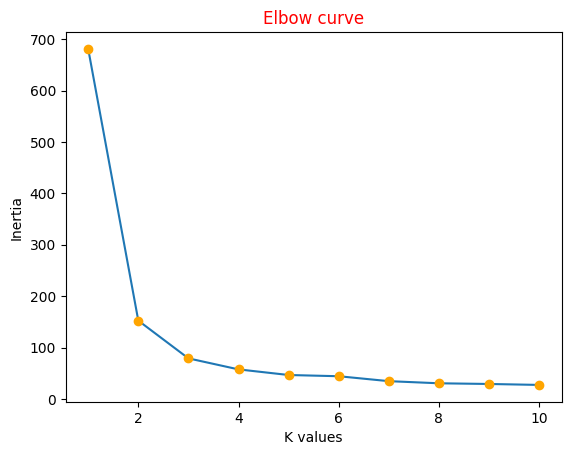

In [7]:
plt.plot(k_values,out,marker="o",markerfacecolor="orange",markeredgecolor='orange')
plt.xlabel("K values")
plt.ylabel("Inertia")
plt.title("Elbow curve",color="red")
plt.show()

In [8]:
model=KMeans(n_clusters=k)
model.fit(x)

KMeans(n_clusters=np.int64(3))

In [14]:
model.inertia_
centroids  = model.cluster_centers_
labels = model.labels_

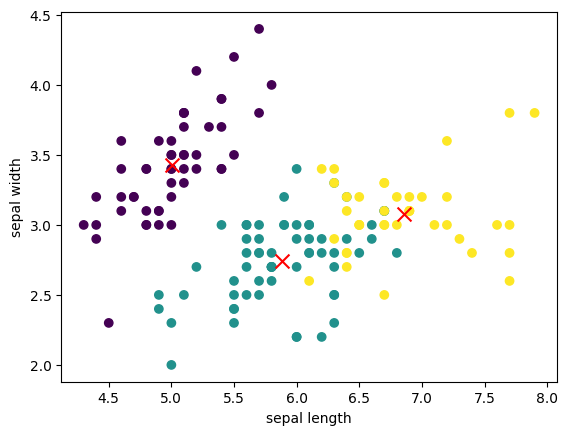

In [16]:
plt.scatter(x[:,0],x[:,1],c=labels)
plt.scatter(centroids[:,0],centroids[:,1],c="red",marker="x",s=100)
plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.show()

Text(0, 0.5, 'petal width')

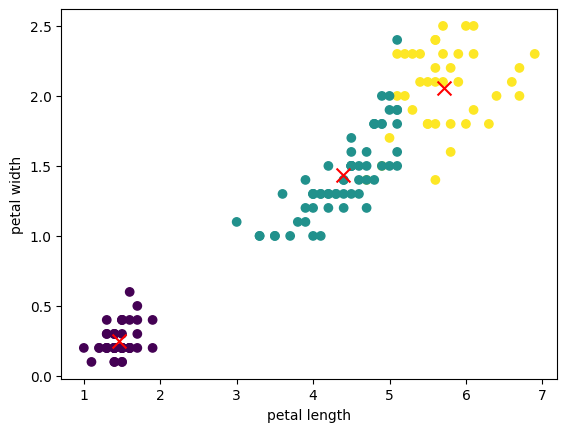

In [18]:
plt.scatter(x[:,2],x[:,3],c=labels)
plt.scatter(centroids[:,2],centroids[:,3],c="red",marker="x",s=100)
plt.xlabel("petal length")
plt.ylabel("petal width")

# Herirarchical clustering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram,linkage,fcluster
from sklearn.datasets import make_blobs

In [ ]:
x,y=make_blobs(n_samples=100,centers=3,cluster_std=1,random_state=42)
x

array([[-7.72642091, -8.39495682],
       [ 5.45339605,  0.74230537],
       [-2.97867201,  9.55684617],
       [ 6.04267315,  0.57131862],
       [-6.52183983, -6.31932507],
       [ 3.64934251,  1.40687195],
       [-2.17793419,  9.98983126],
       [ 4.42020695,  2.33028226],
       [ 4.73695639,  2.94181467],
       [-3.6601912 ,  9.38998415],
       [-3.05358035,  9.12520872],
       [-6.65216726, -5.57296684],
       [-6.35768563, -6.58312492],
       [-3.6155326 ,  7.8180795 ],
       [-1.77073104,  9.18565441],
       [-7.95051969, -6.39763718],
       [-6.60293639, -6.05292634],
       [-2.58120774, 10.01781903],
       [-7.76348463, -6.72638449],
       [-6.40638957, -6.95293851],
       [-2.97261532,  8.54855637],
       [-6.9567289 , -6.53895762],
       [-7.32614214, -6.0237108 ],
       [-2.14780202, 10.55232269],
       [-2.54502366, 10.57892978],
       [-2.96983639, 10.07140835],
       [ 3.22450809,  1.55252436],
       [-6.25395984, -7.73726715],
       [-7.85430886,

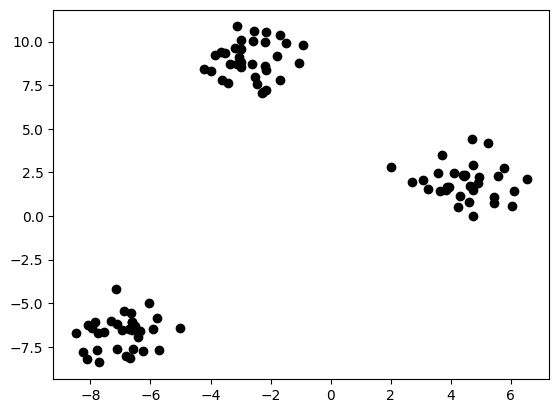

In [ ]:
plt.scatter(x[:,0],x[:,1],c='black')
#all rows from 1st and 2nd row

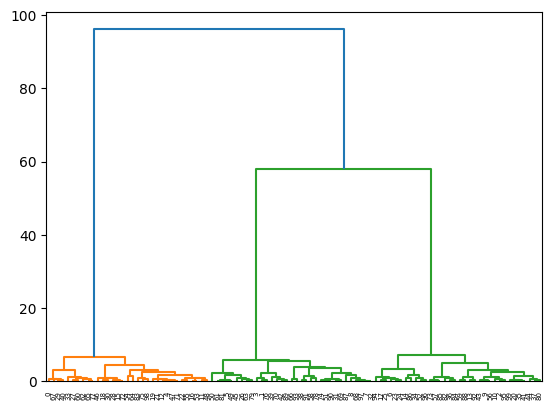

In [ ]:

linked=linkage(x,method='ward')
dendrogram(linked,orientation='top',distance_sort='ascending')
plt.show()
#ward based upen datapointes it will creat clusters
#orientation='top' --> top of each clusters
#method='ward' -> find the cluster

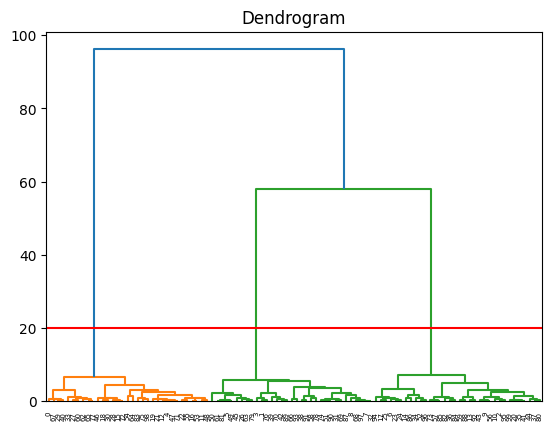

In [ ]:
linked=linkage(x,method='ward')
dendrogram(linked,orientation='top',distance_sort='ascending')
plt.title("Dendrogram")
plt.axhline(20,color='r')
plt.show()

In [ ]:
clusters=fcluster(linked,t=20,criterion='distance')
clusters
# t=20 thrushhold line
#criterion='distance'--> distance

array([1, 2, 3, 2, 1, 2, 3, 2, 2, 3, 3, 1, 1, 3, 3, 1, 1, 3, 1, 1, 3, 1,
       1, 3, 3, 3, 2, 1, 1, 1, 1, 2, 2, 1, 3, 3, 3, 3, 2, 2, 1, 3, 2, 3,
       3, 2, 1, 1, 1, 2, 2, 2, 3, 1, 1, 1, 3, 3, 2, 3, 1, 2, 1, 2, 1, 1,
       2, 1, 2, 2, 2, 1, 1, 3, 2, 1, 2, 1, 2, 2, 3, 2, 3, 1, 3, 3, 3, 2,
       3, 2, 2, 2, 3, 2, 3, 3, 3, 2, 1, 3], dtype=int32)

In [ ]:
n=max(clusters)
n

np.int32(3)

In [ ]:
model=AgglomerativeClustering(n_clusters=n)
model.fit(x)

AgglomerativeClustering(n_clusters=np.int32(3))

In [ ]:
labels=model.labels_
labels

array([1, 2, 0, 2, 1, 2, 0, 2, 2, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 1, 0, 0, 0, 0, 2, 2, 1, 0, 2, 0,
       0, 2, 1, 1, 1, 2, 2, 2, 0, 1, 1, 1, 0, 0, 2, 0, 1, 2, 1, 2, 1, 1,
       2, 1, 2, 2, 2, 1, 1, 0, 2, 1, 2, 1, 2, 2, 0, 2, 0, 1, 0, 0, 0, 2,
       0, 2, 2, 2, 0, 2, 0, 0, 0, 2, 1, 0])

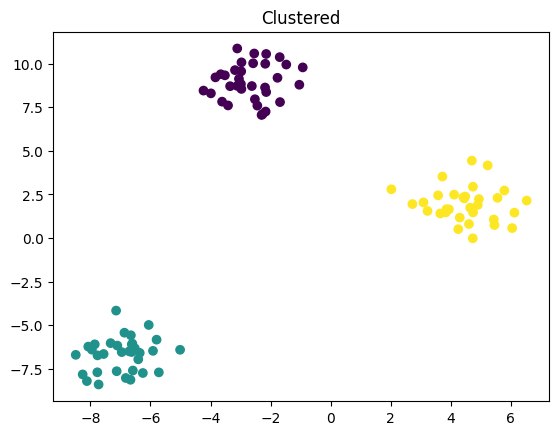

In [ ]:
plt.scatter(x[:,0],x[:,1],c=labels)
plt.title("Clustered")
plt.show()
#c=labels based on labels we can see the muiltpla colors\

In [ ]:
silhouette_score(x,labels)
# it is the performance martix

np.float64(0.8469881221532085)

# DB_SCAN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_moons

In [ ]:
x,y=make_moons(n_samples=1000,noise=0.05,random_state=42)
x

array([[-0.02137124,  0.40618608],
       [ 0.97670045, -0.45832306],
       [ 0.90405882, -0.37651952],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]])

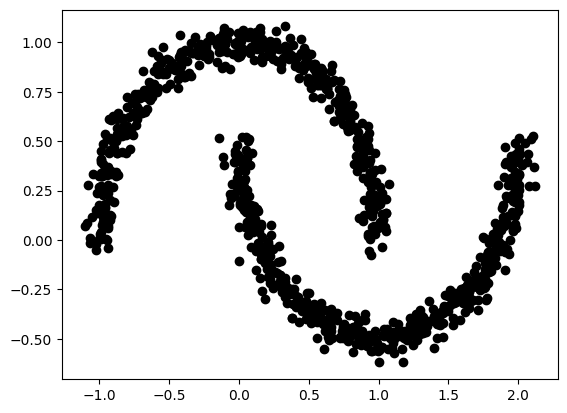

In [ ]:
plt.scatter(x[:,0],x[:,1],c='black')
plt.show()

KMeans

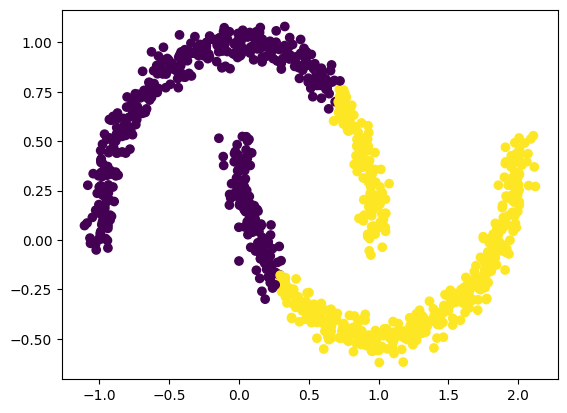

In [ ]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=2)
model.fit(x)
lables=model.labels_
plt.scatter(x[:,0],x[:,1],c=lables)

agglomerative

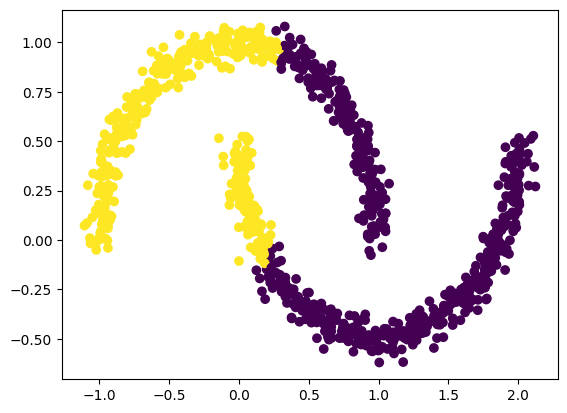

In [ ]:
from sklearn.cluster import AgglomerativeClustering
model_a=AgglomerativeClustering(n_clusters=2)
model_a.fit(x)
lables_a=model_a.labels_
plt.scatter(x[:,0],x[:,1],c=lables_a)

DB_SCAN

In [ ]:
model_db=DBSCAN(eps=0.06,min_samples=3)
model_db.fit(x)

DBSCAN(eps=0.06, min_samples=3)

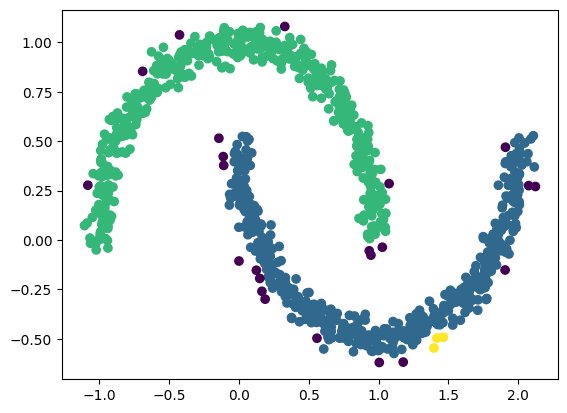

In [ ]:
labels_db=model_db.labels_
plt.scatter(x[:,0],x[:,1],c=labels_db)